# The Validation partition of the dataset

This notebook presents some of the common practices in training a classification model, namely:

- use of a validation set
- early stopping
- learning rate scheduler

# Auxiliary Function

In [1]:
def evaluate(model, data_loader):

    # sets the model in evaluation mode.
    # although our model does not have layers which behave differently during training and evaluation
    # this is a good practice as the models architecture may change in the future
    model.eval()

    correct = 0
    
    for i, (images, targets) in enumerate(data_loader):
         
        # forward pass, compute the output of the model for the current batch
        outputs = model(images.to(device))

        # "max" returns a namedtuple (values, indices) where values is the maximum 
        # value of each row of the input tensor in the given dimension dim; 
        # indices is the index location of each maximum value found (argmax).
        # the argmax effectively provides the predicted class number        
        _, preds = torch.max(outputs, dim=1)

        correct += (preds.cpu() == targets).sum()

    return (correct / len(data_loader.dataset)).item()


# The Dataset

The dataset in this notebook is a subset of GTSRB, a traffic sign dataset. This subset was selected to make it more practical for classroom use. However, the concepts covered here apply to the full dataset as well.

The full dataset can be found in [here](https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/published-archive.html).

GTSRB consists of 43 classes representing various traffic signs. In this subset, we focus exclusively on speed limit signs, which include 8 classes.

Sample images from each class:

![class 0](notebook_images/class0.png) ![class 1](notebook_images/class1.png) ![class 2](notebook_images/class2.png) ![class 3](notebook_images/class3.png) ![class 4](notebook_images/class4.png) ![class 5](notebook_images/class5.png) ![class 6](notebook_images/class6.png) ![class 7](notebook_images/class7.png)

The images are organized into 8 folders, one for each class. The folder name serves as the class label. The folder structures is as follows:

![folder structure](notebook_images/train_folder.png)

Both training and test sets adhere to this format

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms

import torchinfo

import matplotlib.pyplot as plt
import numpy as np
import time

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, 'util')
import vcpi_util

# Dataset loading

In [7]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

PATH_TRAINING_SET = 'd:/vcpi/gtsrb/train_full'
PATH_TEST_SET = 'd:/vcpi/gtsrb/test'

BATCH_SIZE = 32

EPOCHS = 20

cuda:0


As can be seen from the samples above, the image sizes vary. Since the model requires a fixed input size, we need to resize the images to a common dimension. Here, we are going to use 32x32.

In [8]:
transform = transforms.Compose(
    [transforms.Resize((32,32)), transforms.ToTensor()]) 

In [37]:
train_set = torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform = transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

# No shuffle is required for the test set, also the batch size can be completely different
# Shuffling is performed so that we can see images of various classes when inspecting the results
test_set = torchvision.datasets.ImageFolder(root=PATH_TEST_SET, transform = transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = BATCH_SIZE, shuffle=True)

## Dataset info and a sample batch

In [10]:
images, targets = next(iter(train_loader))
print("Batch shape: ", images.shape)

print(targets)

Batch shape:  torch.Size([32, 3, 32, 32])
tensor([7, 6, 2, 1, 1, 2, 5, 6, 2, 5, 1, 5, 3, 4, 6, 7, 4, 4, 7, 6, 7, 3, 3, 1,
        5, 1, 1, 4, 4, 2, 2, 7])


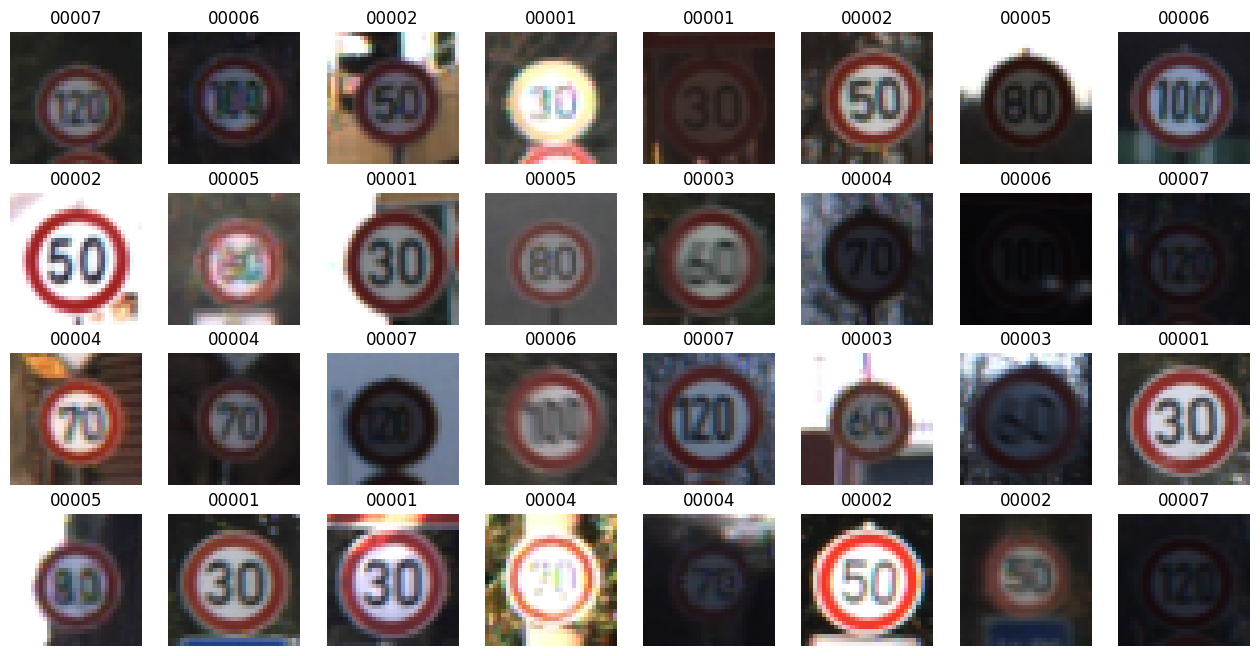

<Figure size 640x480 with 0 Axes>

In [11]:

vcpi_util.show_images(4,8, images, targets, train_set.classes) 

# The model

The *Conv* class defines a convolutional neural network for image classification, processing 32x32 RGB images through convolutional, batch normalization, ReLU, and pooling layers, followed by a fully connected layer for final classification. The output corresponds to the number of classes in the dataset.

In [12]:
class Conv(torch.nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(3, 16, 3)
        self.bn1 = torch.nn.BatchNorm2d(16)
        self.relu1 = torch.nn.ReLU()

        self.conv2 = torch.nn.Conv2d(16, 32, 3)
        self.bn2 = torch.nn.BatchNorm2d(32)
        self.relu2 = torch.nn.ReLU()

        self.maxpool1 = torch.nn.MaxPool2d(2)


        self.conv3 = torch.nn.Conv2d(32, 48, 3)
        self.bn3 = torch.nn.BatchNorm2d(48)
        self.relu3 = torch.nn.ReLU()

        self.conv4 = torch.nn.Conv2d(48, 48, 3)
        self.bn4 = torch.nn.BatchNorm2d(48)
        self.relu4 = torch.nn.ReLU()

        self.maxpool2 = torch.nn.MaxPool2d(2)

        self.fc1 = torch.nn.Linear(1200, num_classes)
        

    def forward(self, x):    
        
        # input = (bs, 3, 32, 32)
        x = self.conv1(x) # -> (bs, 16, 26, 26)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.conv2(x) # -> (bs, 32, 24, 24)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.maxpool1(x)
        
        x = self.conv3(x) # -> (bs, 48, 12, 12)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.conv4(x) # -> (bs, 48, 10, 10)
        x = self.bn4(x)
        x = self.relu4(x)
        x = self.maxpool2(x)
        
        x = torch.flatten(x,1) # -> (bs, 48 * 5 * 5 = 1200)
        x = self.fc1(x)        # -> (bs, 10)

        return(x)


model_Conv_I = Conv(len(train_set.classes))
model_Conv_I.to(device)
print(model_Conv_I)

torchinfo.summary(model_Conv_I, input_size=(BATCH_SIZE, 3, 32, 32))

Conv(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 48, kernel_size=(3, 3), stride=(1, 1))
  (bn3): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (conv4): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1))
  (bn4): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu4): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1200, out_features=8, bias=True)
)


Layer (type:depth-idx)                   Output Shape              Param #
Conv                                     [32, 8]                   --
├─Conv2d: 1-1                            [32, 16, 30, 30]          448
├─BatchNorm2d: 1-2                       [32, 16, 30, 30]          32
├─ReLU: 1-3                              [32, 16, 30, 30]          --
├─Conv2d: 1-4                            [32, 32, 28, 28]          4,640
├─BatchNorm2d: 1-5                       [32, 32, 28, 28]          64
├─ReLU: 1-6                              [32, 32, 28, 28]          --
├─MaxPool2d: 1-7                         [32, 32, 14, 14]          --
├─Conv2d: 1-8                            [32, 48, 12, 12]          13,872
├─BatchNorm2d: 1-9                       [32, 48, 12, 12]          96
├─ReLU: 1-10                             [32, 48, 12, 12]          --
├─Conv2d: 1-11                           [32, 48, 10, 10]          20,784
├─BatchNorm2d: 1-12                      [32, 48, 10, 10]          96
├─R

# Train

In [13]:
def train(model, train_loader, test_loader, epochs, loss_fn, optimizer):

    history = {}
    history['accuracy'] = []
    history['test_acc'] = []
    history['loss'] = []

    for epoch in range(epochs):  # loop over the dataset multiple times

        model.train()
        start_time = time.time() 
        correct = 0
        running_loss = 0.0
        for i, (inputs, targets) in enumerate(train_loader, 0):
            
            # send data to device, hopefully the GPU
            inputs = inputs.to(device)
            targets = targets.to(device)

            # forward pass, compute the output of the model for the current batch
            outputs = model(inputs)


            _, predicted = torch.max(outputs, 1)

            #compute the loss between the model's outputs and the labels, or targets.
            loss = loss_fn(outputs, targets)
            
            # zero the parameter gradients
            # this function must be called before calling "backward" on the losses, otherwise the gradients get accumulated with previous batches.
            optimizer.zero_grad()

            # perform backpropagation
            loss.backward()
            #update the model's parameters
            optimizer.step()

            running_loss += loss
            correct += (predicted == targets).sum()

        model.eval()
        t_correct = 0
        with torch.no_grad():
            for i,t in test_loader:
                i = i.to(device)
                t = t.to(device)
                o = model(i)
                _,p = torch.max(o,1)

                t_correct += (p == t).sum()

        epoch_loss = running_loss / len(train_loader.dataset)
        accuracy = 100 * correct / len(train_loader.dataset)
        t_accuracy = 100 * t_correct / len(test_loader.dataset)
        stop_time = time.time()
        print(f'Epoch: {epoch:03d}; Loss: {epoch_loss:0.4f}; Accuracy: {accuracy:0.4f}; Test_Acc: {t_accuracy:0.4f}; Elapsed time: {(stop_time - start_time):0.4f}')
        history['accuracy'].append(accuracy.cpu().numpy())
        history['test_acc'].append(t_accuracy.cpu().numpy())
        history['loss'].append(running_loss.cpu().detach().numpy())
        
    print('Finished Training')

    return(history)


In [14]:
optimizer_I = torch.optim.Adam(model_Conv_I.parameters())
loss_fn = torch.nn.CrossEntropyLoss()

history_I = train(model_Conv_I, train_loader, test_loader, EPOCHS, loss_fn, optimizer_I)

Epoch: 000; Loss: 0.0137; Accuracy: 85.8764; Test_Acc: 96.1391; Elapsed time: 141.2946
Epoch: 001; Loss: 0.0013; Accuracy: 99.0532; Test_Acc: 97.2662; Elapsed time: 8.6491
Epoch: 002; Loss: 0.0006; Accuracy: 99.6479; Test_Acc: 96.9544; Elapsed time: 8.7366
Epoch: 003; Loss: 0.0003; Accuracy: 99.8044; Test_Acc: 98.1055; Elapsed time: 8.9221
Epoch: 004; Loss: 0.0001; Accuracy: 99.9765; Test_Acc: 98.0096; Elapsed time: 9.0073
Epoch: 005; Loss: 0.0000; Accuracy: 100.0000; Test_Acc: 98.1055; Elapsed time: 8.8203
Epoch: 006; Loss: 0.0008; Accuracy: 99.2332; Test_Acc: 93.5971; Elapsed time: 8.8099
Epoch: 007; Loss: 0.0007; Accuracy: 99.3114; Test_Acc: 97.5300; Elapsed time: 8.8114
Epoch: 008; Loss: 0.0002; Accuracy: 99.8200; Test_Acc: 98.2734; Elapsed time: 9.0857
Epoch: 009; Loss: 0.0003; Accuracy: 99.7966; Test_Acc: 98.4412; Elapsed time: 8.7221
Epoch: 010; Loss: 0.0001; Accuracy: 99.9531; Test_Acc: 98.3933; Elapsed time: 8.5972
Epoch: 011; Loss: 0.0000; Accuracy: 100.0000; Test_Acc: 98.633

In [15]:
torch.save({
        'model':model_Conv_I.state_dict(),
        'optimizer': optimizer_I.state_dict()
        },
        f'model_gtsrb.pt')

Question: Why is the test accuracy higher than the training accuracy in the initial epochs?

# Evaluation

Although they may align, the epoch with the highest training accuracy is not always the one that yields the best test data accuracy.

The issue arises because training accuracy does not always reflect the model's ability to generalize to the test set.

In [16]:
best_train = np.asarray(history_I['accuracy']).argmax()
best_test = np.asarray(history_I['test_acc']).argmax()

print('Best epoch for train accuracy: :', best_train,' Best epoch for test accuracy: :',  best_test)
print('Test accuracy at epoch ',best_train, ' :', history_I['test_acc'][best_train], 'Test accuracy at epoch ',best_test, ' :', history_I['test_acc'][best_test])


Best epoch for train accuracy: : 5  Best epoch for test accuracy: : 17
Test accuracy at epoch  5  : 98.105515 Test accuracy at epoch  17  : 98.82494


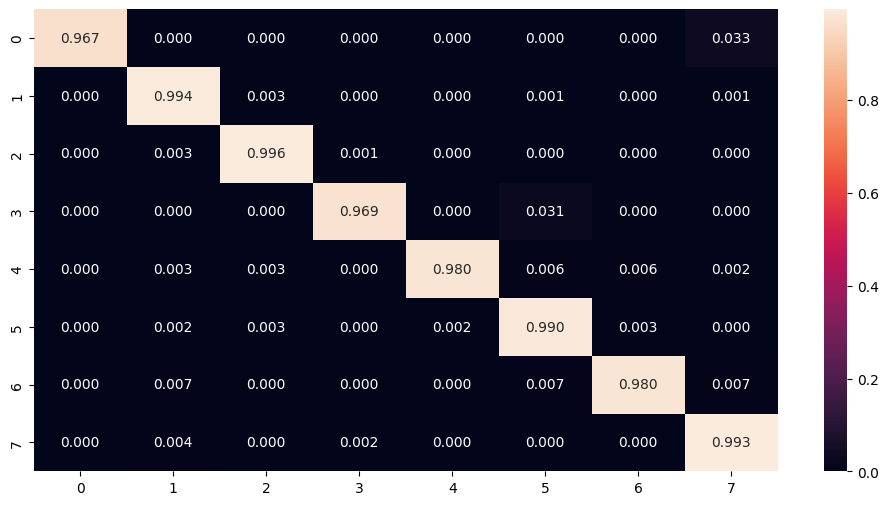

In [17]:
preds = []
ground_truth = []

for images, targets in test_loader:

    logits = model_Conv_I(images.to(device))
    preds_sparse = [np.argmax(x) for x in logits.cpu().detach().numpy()]
    preds.extend(preds_sparse)
    ground_truth.extend(targets.numpy())

vcpi_util.show_confusion_matrix(ground_truth, preds, len(train_set.class_to_idx))

The confusion matrix, derived from predictions on the test set, shows varying accuracy across classes. The histogram below indicates that some classes are underrepresented, which could explain their poorer performance.

- Is there a relationship between class representativeness and accuracy?
- Or is the training set less representative of certain classes?

Both of these factors could potentially explain this behavior.

## Dataset histogram

This dataset is heavily unbalanced, we'll deal with this in later classes

Counter({2: 2250, 1: 2220, 4: 1980, 5: 1860, 6: 1440, 3: 1410, 7: 1410, 0: 210})


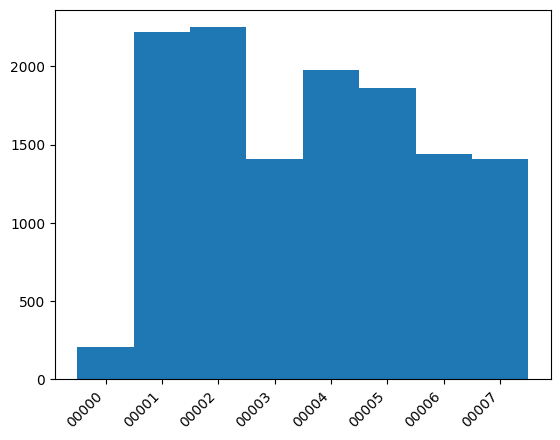

In [18]:
target_list = []
for images, targets in train_loader:
    target_list.extend(targets)

vcpi_util.show_histogram(target_list, train_set.classes)

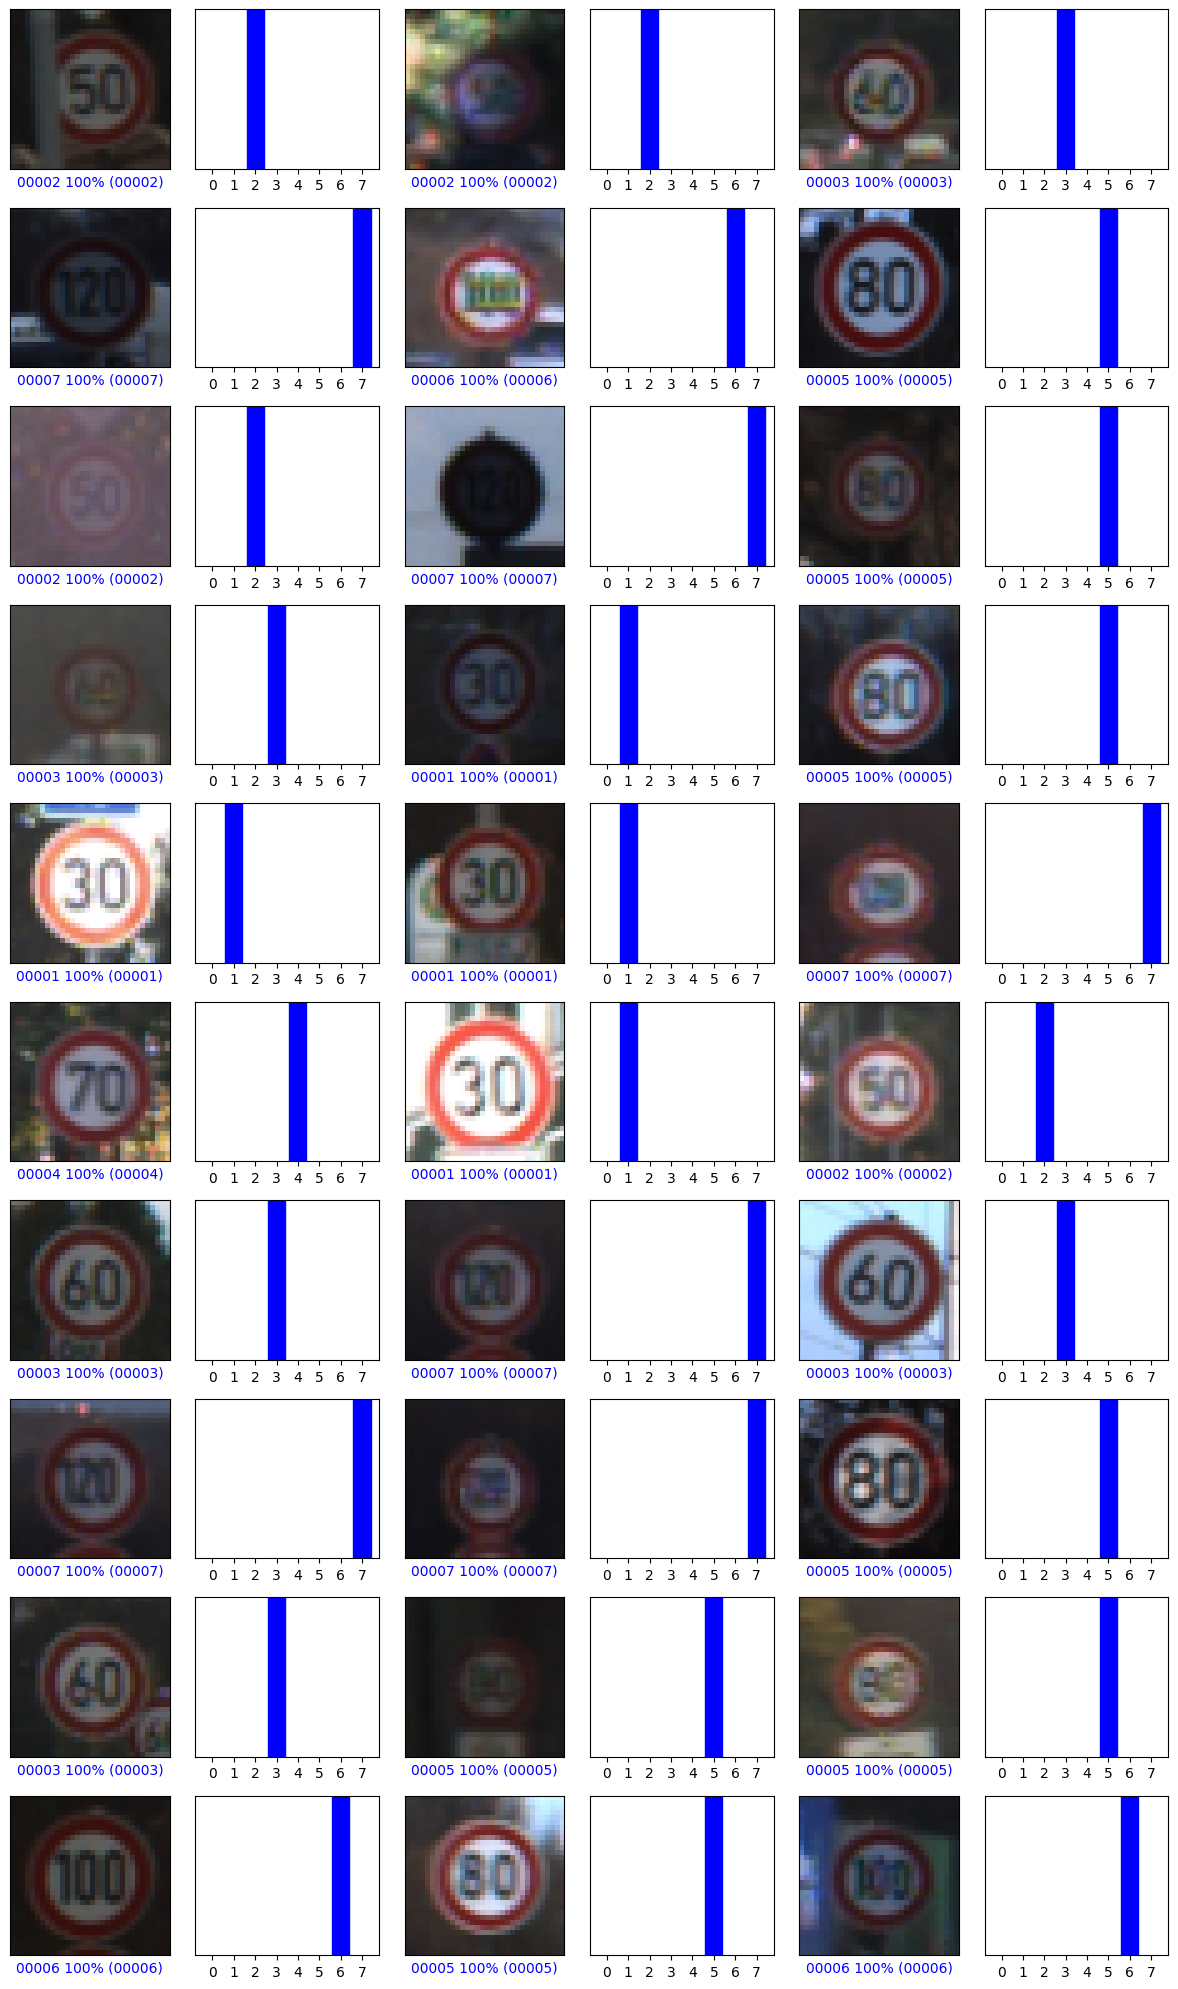

In [38]:
images, targets = next(iter(test_loader))
logits = model_Conv_I(images.to(device))

predictions = torch.nn.functional.softmax(logits, dim=1).cpu().detach().numpy()
vcpi_util.plot_predictions(images, predictions, targets, train_set.classes, 10, 3)

# The Validation Set

Why do we need a third dataset?

- Fine tunning a model to provide a good answer on the test set directly can lead to a model biased towards that dataset.

- Without a separate dataset, we have no way to evaluate how the model will perform on unseen data.

The validation dataset aims at avoiding the training to be solely focused on the training set. This is achieved by having metrics on validation set influence the training process.

This can be achieved without using any of the images of the validation set to compute gradients. Instead, the validation set can be used to guide which model to save, or help adapt hyper parameters such as the learning rate. This is done trough monitoring certain metrics on the validation set, such as the loss.

A good validation set gives an indication of how the model will perform when faced with unseen data. The test dataset can then be used to corroborate this expectation.

## Building the Validation Dataset

One approach to building a validation set is to take a percentage of samples from the train set, i.e. to split the train into two subsets: one for training, and one for validation.

However, having a validation dataset is a compromise, as we are splitting the training data into two subsets: the train and validation datasets. This approach reduces the amount of data available for training the model.



In [20]:
train_sub, val_sub = torch.utils.data.random_split(train_set, [10200, 2580])

train_sub_loader = torch.utils.data.DataLoader(train_sub, batch_size = BATCH_SIZE, shuffle=True)
val_sub_loader = torch.utils.data.DataLoader(val_sub, batch_size = BATCH_SIZE)

A small cosmetic change to the train function, replacing 'test' with 'val' where appropriate.

In [21]:
def train_II(model, train_loader, val_loader, epochs, loss_fn, optimizer):

    

    history = {}
    history['accuracy'] = []
    history['val_acc'] = []
    history['loss'] = []

    for epoch in range(epochs):  # loop over the dataset multiple times

        model.train()
        start_time = time.time() 
        correct = 0
        running_loss = 0.0
        for i, (inputs, targets) in enumerate(train_loader, 0):
            
            # send data to device, hopefully the GPU
            inputs = inputs.to(device)
            targets = targets.to(device)

            # forward pass, compute the output of the model for the current batch
            outputs = model(inputs)


            _, predicted = torch.max(outputs, 1)

            #compute the loss between the model's outputs and the labels, or targets.
            loss = loss_fn(outputs, targets)
            
            # zero the parameter gradients
            # this function must be called before calling "backward" on the losses, otherwise the gradients get accumulated with previous batches.
            optimizer.zero_grad()

            # perform backpropagation
            loss.backward()
            #update the model's parameters
            optimizer.step()

            running_loss += loss
            correct += (predicted == targets).sum()

        model.eval()
        with torch.no_grad():
            v_correct = 0
            for i,t in val_loader:
                i = i.to(device)
                t = t.to(device)
                o = model(i)
                _,p = torch.max(o,1)

                v_correct += (p == t).sum()

        epoch_loss = running_loss / len(train_loader.dataset)
        accuracy = 100 * correct / len(train_loader.dataset)
        v_accuracy = 100 * v_correct / len(val_loader.dataset)
        stop_time = time.time()
        print(f'Epoch: {epoch:03d}; Loss: {epoch_loss:0.4f}; Accuracy: {accuracy:0.4f}; Val Acc: {v_accuracy:0.4f}; Elapsed time: {(stop_time - start_time):0.4f}')
        history['accuracy'].append(accuracy.cpu().numpy())
        history['val_acc'].append(v_accuracy.cpu().numpy())
        history['loss'].append(running_loss.cpu().detach().numpy())
        
    print('Finished Training')

    return(history)

## Training and evaluating

In [22]:
model_Conv_II = Conv(len(train_set.classes))
model_Conv_II.to(device)

optimizer_II = torch.optim.Adam(model_Conv_II.parameters())


In [23]:
history_II = train_II(model_Conv_II, train_sub_loader, val_sub_loader, EPOCHS, loss_fn, optimizer_II)

Epoch: 000; Loss: 0.0154; Accuracy: 83.9020; Val Acc: 96.5504; Elapsed time: 6.6279
Epoch: 001; Loss: 0.0013; Accuracy: 99.1667; Val Acc: 98.6047; Elapsed time: 6.5940
Epoch: 002; Loss: 0.0007; Accuracy: 99.5196; Val Acc: 98.8372; Elapsed time: 6.6818
Epoch: 003; Loss: 0.0003; Accuracy: 99.8039; Val Acc: 99.3411; Elapsed time: 6.6322
Epoch: 004; Loss: 0.0002; Accuracy: 99.9412; Val Acc: 98.4884; Elapsed time: 6.6658
Epoch: 005; Loss: 0.0005; Accuracy: 99.6274; Val Acc: 97.5194; Elapsed time: 6.6952
Epoch: 006; Loss: 0.0003; Accuracy: 99.7647; Val Acc: 99.1473; Elapsed time: 6.6958
Epoch: 007; Loss: 0.0001; Accuracy: 99.9510; Val Acc: 99.4186; Elapsed time: 6.6730
Epoch: 008; Loss: 0.0000; Accuracy: 100.0000; Val Acc: 99.6124; Elapsed time: 6.6496
Epoch: 009; Loss: 0.0000; Accuracy: 100.0000; Val Acc: 99.5736; Elapsed time: 6.6618
Epoch: 010; Loss: 0.0000; Accuracy: 100.0000; Val Acc: 99.5736; Elapsed time: 6.6932
Epoch: 011; Loss: 0.0000; Accuracy: 100.0000; Val Acc: 99.5736; Elapsed t

In [24]:
torch.save({
        'model':model_Conv_II.state_dict(),
        'optimizer': optimizer_II.state_dict()
        },
        f'model_gtsrb_val_I.pt')

In [25]:
evaluate(model_Conv_II, test_loader)

0.986810564994812

As can be seen from the losses of the test and validation sets, we have not achieved our goal. The validation loss closely mirrors the training loss, and it is not a reliable predictor of the test loss.

This suggests that we should examine the data to see how we are splitting the original training set, as it may be influencing the observed results.

## Inspecting the dataset

The GTSRB training data consist of video sequences, each with 30 frames, leading to strong image correlation within each sequence.

By randomly sampling the original training set to gather images for the validation set, we are, in average, taking a small percentage of images in each sequence. This implies that the training set may have very similar images to those in the validation set, causing the reported losses and accuracies to be closely aligned.

An approach to address this issue is to build the validation set by gathering entire sequences from the training set. 

## Build the new validation dataset

Taking into account what we said before, the new validation set will be build using full sequences from the training set, so instead of taking 20% of samples ramdomly, we built the validation dataset with approximately 20% of the sequences.

In [27]:
PATH_VAL_SET = 'd:/vcpi/gtsrb/val'

val_set = torchvision.datasets.ImageFolder(root=PATH_VAL_SET, transform = transform)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = BATCH_SIZE)

PATH_TRAIN_PARTIAL_SET = 'd:/vcpi/gtsrb/train'

train_partial = torchvision.datasets.ImageFolder(root=PATH_TRAIN_PARTIAL_SET, transform = transform)
train_partial_loader = torch.utils.data.DataLoader(train_partial, batch_size = BATCH_SIZE,shuffle=True)

## Train and evaluate

In [28]:
model_Conv_III = Conv(len(train_set.classes))
model_Conv_III.to(device)

optimizer_III = torch.optim.Adam(model_Conv_III.parameters())

history_III = train_II(model_Conv_III, train_partial_loader, val_loader, EPOCHS, loss_fn, optimizer_III)

Epoch: 000; Loss: 0.0152; Accuracy: 84.2941; Val Acc: 88.1008; Elapsed time: 102.3136
Epoch: 001; Loss: 0.0013; Accuracy: 99.1274; Val Acc: 93.1395; Elapsed time: 6.6446
Epoch: 002; Loss: 0.0003; Accuracy: 99.9216; Val Acc: 96.6279; Elapsed time: 6.6207
Epoch: 003; Loss: 0.0001; Accuracy: 99.9804; Val Acc: 96.7442; Elapsed time: 6.6218
Epoch: 004; Loss: 0.0001; Accuracy: 99.9902; Val Acc: 97.0543; Elapsed time: 6.6048
Epoch: 005; Loss: 0.0000; Accuracy: 100.0000; Val Acc: 96.7829; Elapsed time: 6.5319
Epoch: 006; Loss: 0.0000; Accuracy: 100.0000; Val Acc: 96.9380; Elapsed time: 6.5232
Epoch: 007; Loss: 0.0000; Accuracy: 100.0000; Val Acc: 96.8992; Elapsed time: 6.5715
Epoch: 008; Loss: 0.0000; Accuracy: 100.0000; Val Acc: 96.9380; Elapsed time: 6.7008
Epoch: 009; Loss: 0.0000; Accuracy: 100.0000; Val Acc: 96.8217; Elapsed time: 6.4614
Epoch: 010; Loss: 0.0000; Accuracy: 100.0000; Val Acc: 96.9380; Elapsed time: 6.6914
Epoch: 011; Loss: 0.0000; Accuracy: 100.0000; Val Acc: 97.0155; Elap

In [29]:
torch.save({
        'model':model_Conv_III.state_dict(),
        'optimizer': optimizer_III.state_dict()
        },
        f'model_gtsrb_val_II.pt')

In [30]:
evaluate(model_Conv_III, test_loader)

0.9851319193840027

As can be seen, the validation and test accuracies are now much closer, and the validation metrics serve as a more reliable indicator of the test metrics.

Thus, we have successfully achieved our goal with the validation set.

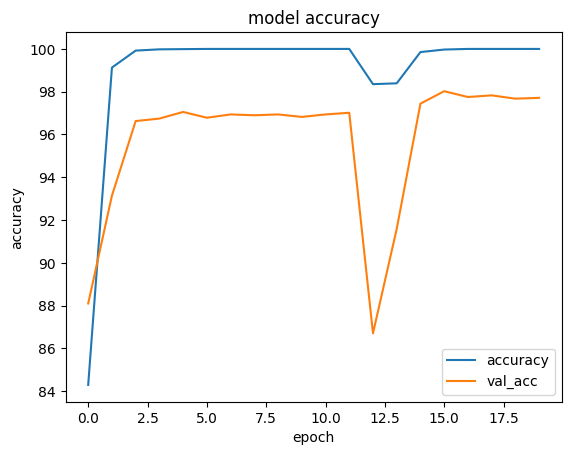

In [31]:
vcpi_util.show_history_plus(history_III, ['accuracy', 'val_acc'])

# Early Stopping and Learning Rate Scheduler

## Early Stopping

The early stopping criterion allows us to set a higher number of epochs without the concern of wasting training time. If the model learns quickly, training will stop early; if the model takes longer to train, it won't be stopped prematurely due to a limited number of epochs.

In [32]:
class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta

        self.min_delta
        self.min_val_loss = float('inf')

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
            
        return False


## Learning Rate Scheduler

A learning rate scheduler adjusts the learning rate during training. 

It usually depends only on the number of epochs or batches. Some optimizers start with a large learning rate, and gradually decrease it over time, while others use a warmup period, increasing the learning rate faster in the beginning, and then decreasing it over a longer period of time. 

Alternatively, the learning rate can be adjusted based on the progress of a specific metric, such as the loss. For example, we can reduce the learning rate when the model is no longer making progress after a number of epochs. This is known as the "reduce on plateau" approach.

The list of schedulers implemented in torch can be found in the [Documentation](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate)

c:\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:143: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


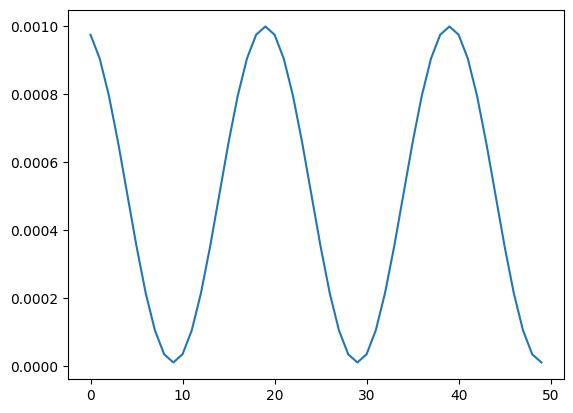

In [33]:
optimizer_aux = torch.optim.Adam(model_Conv_III.parameters(), lr=0.001)

#scheduler = torch.optim.lr_scheduler.LinearLR(optimizer_aux, start_factor=1, end_factor=0.1, total_iters =20)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_aux, 10, 0.00001)

lrs = []
for epoch in range(50):
    scheduler.step()
    lrs.append(scheduler.get_last_lr())

plt.plot(lrs)


In [34]:
def train_III(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, save_prefix = 'model'):

    history = {}
    history['accuracy'] = []
    history['val_acc'] = []
    history['val_loss'] = []
    history['loss'] = []
    best_val_loss = np.inf

    for epoch in range(epochs):  # loop over the dataset multiple times

        model.train()
        start_time = time.time() 
        correct = 0
        running_loss = 0.0
        for i, (inputs, targets) in enumerate(train_loader, 0):
            
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            loss = loss_fn(outputs, targets)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss
            correct += (predicted == targets).sum()

        model.eval()
        with torch.no_grad():
            v_correct = 0
            val_loss = 0.0
            for i,t in val_loader:
                i = i.to(device)
                t = t.to(device)
                o = model(i)
                _,p = torch.max(o,1)
                
                val_loss += loss_fn(o, t)

                v_correct += (p == t).sum()

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if old_lr != new_lr:
            print('==> Learning rate updated: ', old_lr, ' -> ', new_lr)

        epoch_loss = running_loss / len(train_loader.dataset)
        accuracy = 100 * correct / len(train_loader.dataset)
        v_accuracy = 100 * v_correct / len(val_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)
        stop_time = time.time()
        print(f'Epoch: {epoch:03d}; Loss: {epoch_loss:0.6f}; Accuracy: {accuracy:0.4f}; Val Loss: {val_loss:0.6f}; Val Acc: {v_accuracy:0.4f}; Elapsed time: {(stop_time - start_time):0.4f}')
        history['accuracy'].append(accuracy.cpu().numpy())
        history['val_acc'].append(v_accuracy.cpu().numpy())
        history['val_loss'].append(val_loss.cpu().detach().numpy())
        history['loss'].append(epoch_loss.cpu().detach().numpy())
 
        ###### Saving ######
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model':model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict()
                },
                f'{save_prefix}_{epoch}.pt')

        if early_stopper(val_loss):
            print('Early stopping!')
            break
        
    print('Finished Training')

    return(history)


In [35]:
model_Conv_IV = Conv(len(train_set.classes))
model_Conv_IV.to(device)

optimizer_IV = torch.optim.Adam(model_Conv_IV.parameters())
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_IV, mode='min', factor = 0.1, patience=3)

early_stop = Early_Stopping(9)

history_IV = train_III(model_Conv_IV, train_partial_loader, val_loader, 100, loss_fn, optimizer_IV, scheduler, early_stop, 'model_gtsrb_best')

Epoch: 000; Loss: 0.015527; Accuracy: 83.9510; Val Loss: 0.008105; Val Acc: 90.8915; Elapsed time: 6.7549
Epoch: 001; Loss: 0.001155; Accuracy: 99.2451; Val Loss: 0.007766; Val Acc: 90.6589; Elapsed time: 6.7563
Epoch: 002; Loss: 0.000479; Accuracy: 99.7157; Val Loss: 0.005515; Val Acc: 93.7209; Elapsed time: 6.8459
Epoch: 003; Loss: 0.000327; Accuracy: 99.7941; Val Loss: 0.005244; Val Acc: 94.1085; Elapsed time: 6.9395
Epoch: 004; Loss: 0.000130; Accuracy: 99.9608; Val Loss: 0.002958; Val Acc: 96.8605; Elapsed time: 6.9034
Epoch: 005; Loss: 0.000026; Accuracy: 100.0000; Val Loss: 0.002281; Val Acc: 97.4419; Elapsed time: 6.7773
Epoch: 006; Loss: 0.000013; Accuracy: 100.0000; Val Loss: 0.002289; Val Acc: 97.3256; Elapsed time: 6.6079
Epoch: 007; Loss: 0.000009; Accuracy: 100.0000; Val Loss: 0.002330; Val Acc: 97.4419; Elapsed time: 6.8764
Epoch: 008; Loss: 0.000007; Accuracy: 100.0000; Val Loss: 0.002145; Val Acc: 97.7132; Elapsed time: 6.8496
Epoch: 009; Loss: 0.000005; Accuracy: 100.

In [49]:
reload = torch.load(f'model_gtsrb_best_26.pt')
print(reload['epoch'])
model_Conv_best = Conv(len(train_set.classes))
model_Conv_best.to(device)
model_Conv_best.load_state_dict(reload['model'])
evaluate(model_Conv_best, test_loader)

26


0.9798561334609985

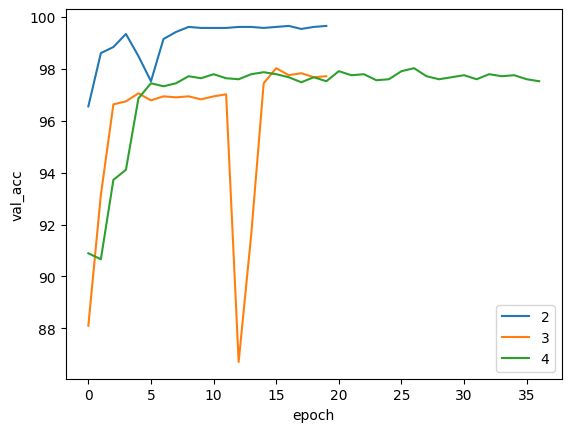

In [36]:
vcpi_util.show_histories([history_II, history_III, history_IV],['2','3','4'], 'val_acc')